# StrategyLooper Review Notebook

Run this notebook after running `python main.py`, or use the optional search cell below to regenerate results. The notebook uses the project backtester and renders charts with inline SVG, so it does not require pandas or matplotlib.

Run all cells from the top. The setup/helper cells may only print a short status message; charts start in the sections titled `Summary verdict`, `Top strategies and failures`, and below.

In [11]:
from pathlib import Path
from collections import Counter, defaultdict
from html import escape
import csv
import json
import math

from IPython.display import HTML, SVG, display

import strategy_research as sr
import review_report

ROOT = Path.cwd()
DATA_DIR = ROOT / 'data'
RESULTS_DIR = ROOT / 'results'
REPORT_PATH = RESULTS_DIR / 'latest_strategy_search.json'

def load_report(path=REPORT_PATH):
    candidates = []
    if path.exists():
        candidates.append(path)
    candidates.extend(
        sorted(
            RESULTS_DIR.glob('strategy_search_*.json'),
            key=lambda item: item.stat().st_mtime,
            reverse=True,
        )
    )
    seen = set()
    errors = []
    for candidate in candidates:
        if candidate in seen:
            continue
        seen.add(candidate)
        try:
            loaded = json.loads(candidate.read_text(encoding='utf-8'))
        except json.JSONDecodeError as exc:
            errors.append(f'{candidate.name}: {exc}')
            continue
        print('Loaded report:', candidate)
        if errors:
            print('Skipped invalid report files:', '; '.join(errors[:3]))
        return loaded, candidate
    raise FileNotFoundError('No valid strategy report JSON found. Run python main.py first.')

report, REPORT_PATH = load_report()
print('Status:', report.get('status'))
HTML_REPORT_PATH = review_report.write_html_report()
print('Standalone HTML report written to:', HTML_REPORT_PATH)

Loaded report: E:\Coding Projects\StrategyLooper\results\latest_strategy_search.json
Status: passed
Standalone HTML report written to: E:\Coding Projects\StrategyLooper\results\latest_strategy_review.html


## Optional: regenerate the latest report

Uncomment and run the next cell if you want the notebook to create fresh results before reviewing.

In [12]:
# sr.main(['--max-trials', '1200', '--time-budget-sec', '90', '--keep-searching-after-pass'])
# report, REPORT_PATH = load_report()

In [13]:
def pct(value):
    if value is None:
        return ''
    return f'{float(value) * 100:.2f}%'

def num(value, digits=3):
    if value is None:
        return ''
    return f'{float(value):.{digits}f}'

def chart_value(value):
    if value is None or value == '':
        return 0.0
    if isinstance(value, str):
        text = value.strip()
        if text.endswith('%'):
            return float(text[:-1]) / 100.0
        return float(text)
    return float(value)

def read_csv_rows(path):
    path = Path(path)
    if not path.exists():
        return []
    with path.open(encoding='utf-8', newline='') as handle:
        return list(csv.DictReader(handle))

def html_table(rows, columns=None, limit=20, title=None):
    rows = list(rows)[:limit]
    if not rows:
        display(HTML('<p>No rows.</p>'))
        return
    columns = columns or list(rows[0].keys())
    head = ''.join(f'<th>{escape(str(col))}</th>' for col in columns)
    body = []
    for row in rows:
        body.append('<tr>' + ''.join(f'<td>{escape(str(row.get(col, "")))}</td>' for col in columns) + '</tr>')
    caption = f'<h3>{escape(title)}</h3>' if title else ''
    display(HTML(caption + '<table style="border-collapse:collapse;font-size:13px">'
                 + '<thead><tr>' + head + '</tr></thead><tbody>'
                 + ''.join(body) + '</tbody></table>'
                 + '<style>td,th{border:1px solid #ddd;padding:4px 6px;text-align:right} th{text-align:center;background:#f5f5f5}</style>'))

def points_for_series(values, width, height, pad):
    clean = [float(v) for v in values]
    if not clean:
        return '', 0, 0
    lo, hi = min(clean), max(clean)
    if math.isclose(lo, hi):
        lo -= 1.0
        hi += 1.0
    pts = []
    for idx, value in enumerate(clean):
        x = pad + idx * (width - 2 * pad) / max(1, len(clean) - 1)
        y = height - pad - (value - lo) * (height - 2 * pad) / (hi - lo)
        pts.append(f'{x:.1f},{y:.1f}')
    return ' '.join(pts), lo, hi

def line_chart(series, title, width=980, height=320, color='#1f77b4'):
    values = [v for _, v in series]
    pts, lo, hi = points_for_series(values, width, height, 36)
    if not pts:
        display(HTML('<p>No chart data.</p>'))
        return
    svg = f'''<svg width="{width}" height="{height}" viewBox="0 0 {width} {height}" xmlns="http://www.w3.org/2000/svg">
      <rect width="100%" height="100%" fill="white"/>
      <text x="20" y="22" font-size="16" font-family="Arial">{escape(title)}</text>
      <line x1="36" y1="{height-36}" x2="{width-20}" y2="{height-36}" stroke="#bbb"/>
      <line x1="36" y1="36" x2="36" y2="{height-36}" stroke="#bbb"/>
      <text x="42" y="50" font-size="11" font-family="Arial">{hi:.2f}</text>
      <text x="42" y="{height-44}" font-size="11" font-family="Arial">{lo:.2f}</text>
      <polyline points="{pts}" fill="none" stroke="{color}" stroke-width="2"/>
    </svg>'''
    display(SVG(svg))

def bar_chart(rows, label_key, value_key, title, width=980, height=360, color='#4c78a8'):
    rows = list(rows)
    if not rows:
        display(HTML('<p>No chart data.</p>'))
        return
    labels = [str(r[label_key]) for r in rows]
    values = [chart_value(r[value_key]) for r in rows]
    lo = min(0.0, min(values))
    hi = max(0.0, max(values))
    if math.isclose(lo, hi):
        hi = lo + 1.0
    pad_l, pad_b, pad_t = 56, 80, 36
    plot_w = width - pad_l - 20
    plot_h = height - pad_t - pad_b
    bar_w = plot_w / max(1, len(values)) * 0.72
    zero_y = pad_t + (hi - 0.0) * plot_h / (hi - lo)
    bars = []
    for idx, (label, value) in enumerate(zip(labels, values)):
        x = pad_l + idx * plot_w / max(1, len(values)) + bar_w * 0.15
        y = pad_t + (hi - max(value, 0.0)) * plot_h / (hi - lo)
        h = abs(value) * plot_h / (hi - lo)
        if value < 0:
            y = zero_y
        bars.append(f'<rect x="{x:.1f}" y="{y:.1f}" width="{bar_w:.1f}" height="{h:.1f}" fill="{color}"/>')
        bars.append(f'<text x="{x + bar_w/2:.1f}" y="{height-18}" font-size="10" text-anchor="middle" transform="rotate(45 {x + bar_w/2:.1f},{height-18})" font-family="Arial">{escape(label[:18])}</text>')
    svg = f'''<svg width="{width}" height="{height}" viewBox="0 0 {width} {height}" xmlns="http://www.w3.org/2000/svg">
      <rect width="100%" height="100%" fill="white"/>
      <text x="20" y="22" font-size="16" font-family="Arial">{escape(title)}</text>
      <line x1="{pad_l}" y1="{zero_y:.1f}" x2="{width-20}" y2="{zero_y:.1f}" stroke="#999"/>
      <text x="8" y="{pad_t+12}" font-size="11" font-family="Arial">{hi:.2f}</text>
      <text x="8" y="{height-pad_b}" font-size="11" font-family="Arial">{lo:.2f}</text>
      {''.join(bars)}
    </svg>'''
    display(SVG(svg))

print('Notebook helper functions loaded. Continue running the next cells to render tables and charts.')


Notebook helper functions loaded. Continue running the next cells to render tables and charts.


## 1. Summary verdict

This cell shows the selected candidate and the two validation statuses. A candidate is not ready for live trading if either robustness or walk-forward is flagged.

In [14]:
found = report.get('found')
robustness = report.get('robustness') or {}
walk_forward = report.get('walk_forward') or {}

summary_rows = []
if found:
    summary_rows.append({
        'strategy': found['strategy_label'],
        'universe': found['universe'],
        'test_sharpe': num(found['test']['sharpe']),
        'test_ann_return': pct(found['test']['annual_return']),
        'test_max_dd': pct(found['test']['max_drawdown']),
        'positive_test_markets': pct(found['positive_test_market_fraction']),
        'robustness': robustness.get('status', 'not_run'),
        'walk_forward': walk_forward.get('status', 'not_run'),
    })
html_table(summary_rows, title='Selected candidate')
print('Robustness warnings:', ', '.join(robustness.get('warnings', [])) or 'none')
print('Walk-forward warnings:', ', '.join(walk_forward.get('warnings', [])) or 'none')

strategy,universe,test_sharpe,test_ann_return,test_max_dd,positive_test_markets,robustness,walk_forward
"momentum(lookback=180, threshold=0.1, side=long)",softs,1.492,37.34%,21.52%,100.00%,flagged,passed


Robustness warnings: selected_universe_has_four_or_fewer_markets, train_drawdown_exceeds_test_drawdown_limit, validation_drawdown_exceeds_test_drawdown_limit, less_than_half_of_parameter_neighbors_passed
Walk-forward warnings: none


## 2. Top strategies and failures

Use this to compare the best strategies. A high score is not enough: failed reasons usually identify excessive drawdown, weak validation, or too few positive markets.

rank,passed,universe,strategy,test_sharpe,test_annual_return,test_max_drawdown,positive_test_market_fraction,failed_reasons
1,True,softs,"momentum(lookback=180, threshold=0.1, side=long)",1.491924,0.373423,0.215173,1.0,
2,False,softs,"momentum(lookback=20, threshold=0.02, side=inverse)",0.854954,0.439315,0.377106,0.75,test_drawdown>0.25
3,True,softs,"momentum(lookback=180, threshold=0.05, side=long)",1.384141,0.354274,0.243378,1.0,
4,False,softs,"momentum(lookback=180, threshold=0.02, side=long)",1.236899,0.31269,0.258093,1.0,train_sharpe<0.1;test_drawdown>0.25
5,True,commodities,"momentum(lookback=60, threshold=0.02, side=inverse)",0.875177,0.139865,0.201797,0.607143,
6,True,commodities,"momentum(lookback=60, threshold=0.1, side=inverse)",0.866036,0.126588,0.191753,0.535714,
7,False,softs,"momentum(lookback=180, threshold=0.0, side=long)",1.231543,0.313593,0.258035,1.0,test_drawdown>0.25
8,False,softs,"momentum(lookback=20, threshold=0.0, side=inverse)",0.778302,0.377869,0.388576,0.5,test_drawdown>0.25
9,True,commodities,"momentum(lookback=60, threshold=0.05, side=inverse)",0.785517,0.119901,0.200697,0.571429,
10,False,commodities,"momentum(lookback=60, threshold=0.0, side=inverse)",0.858821,0.138516,0.203623,0.464286,positive_market_fraction<0.5


reason,count
test_sharpe<0.75,1073
test_annual_return<0.05,966
positive_market_fraction<0.5,890
validation_sharpe<0.1,718
validation_annual_return<=0,692
train_sharpe<0.1,684
test_drawdown>0.25,639
exposure<0.08,55


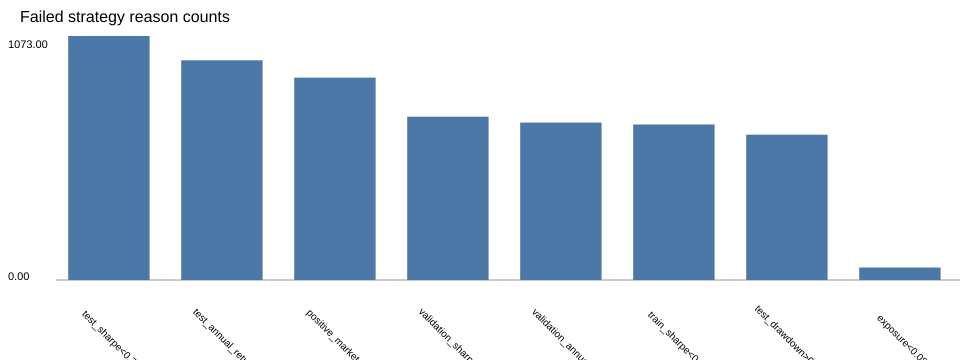

In [15]:
top_rows = read_csv_rows(RESULTS_DIR / 'latest_strategy_search.csv')
failed_rows = read_csv_rows(RESULTS_DIR / 'latest_strategy_search_failed.csv')
html_table(top_rows, columns=['rank','passed','universe','strategy','test_sharpe','test_annual_return','test_max_drawdown','positive_test_market_fraction','failed_reasons'], limit=15, title='Top ranked strategies')

reason_counts = Counter()
for row in failed_rows:
    for reason in row.get('failed_reasons', '').split(';'):
        if reason:
            reason_counts[reason] += 1
reason_rows = [{'reason': key, 'count': value} for key, value in reason_counts.most_common(12)]
html_table(reason_rows, title='Most common failure reasons')
bar_chart(reason_rows, 'reason', 'count', 'Failed strategy reason counts')

## 3. Rebuild selected strategy equity and drawdown

This recomputes the selected candidate from raw `.dat` files. The important check is whether the equity curve is smooth enough and whether drawdowns are acceptable across train, validation, and test.

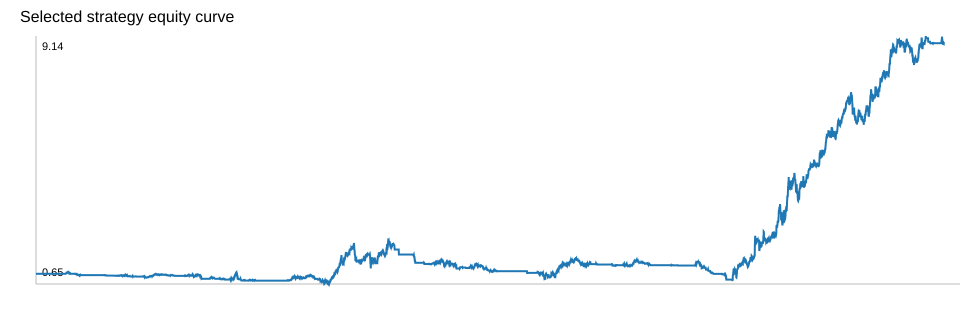

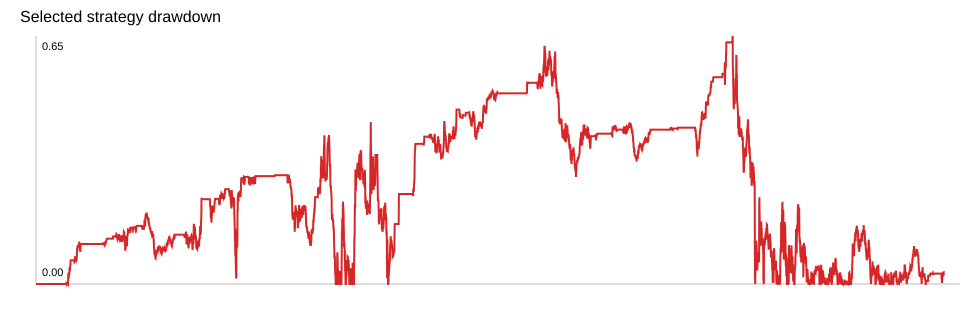

In [16]:
def variant_from_dict(data):
    return sr.StrategyVariant(
        family=data['family'],
        params=tuple(sorted(data['params'].items())),
        side=data['side'],
    )

def aggregate_daily_series(runs, symbols):
    bucket = defaultdict(lambda: [0.0, 0.0])
    for symbol in symbols:
        run = runs[symbol]
        for one_date, value in zip(run.dates, run.returns):
            bucket[one_date][0] += value
            bucket[one_date][1] += 1.0
    rows = []
    for one_date in sorted(bucket):
        total, count = bucket[one_date]
        rows.append((one_date, total / count if count else 0.0))
    return rows

def equity_and_drawdown(return_series):
    equity = 1.0
    high = 1.0
    equity_series = []
    drawdown_series = []
    for one_date, value in return_series:
        equity *= max(0.0, 1.0 + value)
        high = max(high, equity)
        drawdown = (high - equity) / high if high else 0.0
        equity_series.append((one_date, equity))
        drawdown_series.append((one_date, drawdown))
    return equity_series, drawdown_series

markets = sr.load_markets(DATA_DIR, min_bars=750)
universes = sr.build_universes(markets)
market_by_symbol = {market.symbol: market for market in markets}
variant = variant_from_dict(found['strategy'])
symbols = universes[found['universe']]
selected_markets = [market_by_symbol[symbol] for symbol in symbols]
runs = sr.backtest_variant(selected_markets, variant, report['criteria']['cost_bps'])
daily_returns = aggregate_daily_series(runs, symbols)
equity_series, drawdown_series = equity_and_drawdown(daily_returns)
line_chart(equity_series, 'Selected strategy equity curve')
line_chart(drawdown_series, 'Selected strategy drawdown', color='#d62728')

## 4. Train / validation / test metrics

You want the test period to be good, but not wildly better than train and validation. A huge test-only improvement is a warning sign.

split,days,total_return,annual_return,sharpe,max_drawdown,win_rate,profit_factor
train,3508,36.03%,2.24%,0.210,62.30%,29.33%,1.055
validation,1174,51.11%,9.27%,0.441,48.34%,24.79%,1.162
test,1167,334.67%,37.34%,1.492,21.52%,49.19%,1.342


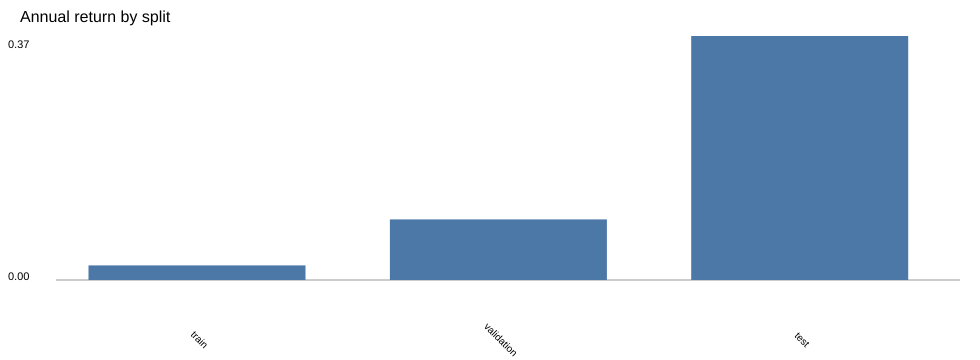

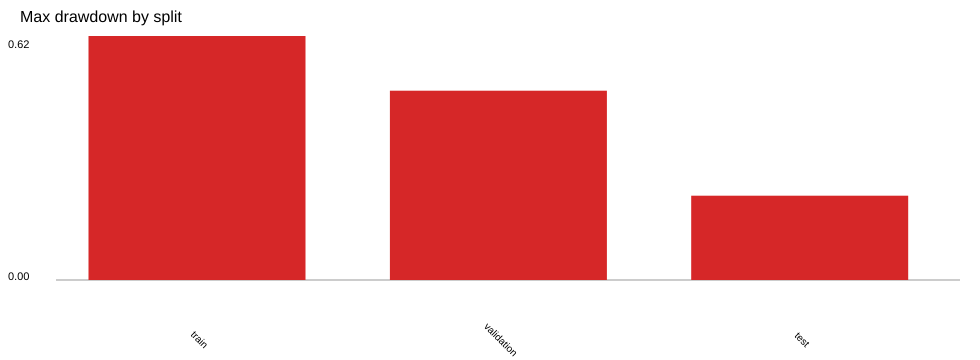

In [17]:
split_rows = []
for split in ['train', 'validation', 'test']:
    metrics = found[split]
    split_rows.append({
        'split': split,
        'days': metrics['days'],
        'total_return': pct(metrics['total_return']),
        'annual_return': pct(metrics['annual_return']),
        'sharpe': num(metrics['sharpe']),
        'max_drawdown': pct(metrics['max_drawdown']),
        'win_rate': pct(metrics['win_rate']),
        'profit_factor': num(metrics['profit_factor']),
    })
html_table(split_rows, title='Selected strategy split metrics')
bar_chart(split_rows, 'split', 'annual_return', 'Annual return by split')
bar_chart(split_rows, 'split', 'max_drawdown', 'Max drawdown by split', color='#d62728')

## 5. Robustness checks

Look for nearby parameters, higher-cost versions, and leave-one-out variants that still pass. If only one exact configuration works, treat it as overfit.

item,passed,test_sharpe,test_annual_return,test_max_drawdown,failed_reasons
2.0bps,True,1.491924,0.373423,0.215173,
4.0bps,True,1.486644,0.371738,0.215173,
6.0bps,True,1.481363,0.370055,0.215173,
10.0bps,True,1.470794,0.366696,0.215173,


item,passed,test_sharpe,test_annual_return,test_max_drawdown,failed_reasons
@CT,False,1.507197,0.496361,0.278414,train_sharpe<0.1;test_drawdown>0.25
@KC,False,1.261613,0.3675,0.298821,test_drawdown>0.25
@OJ,True,0.803313,0.115606,0.145266,
@SB,False,1.519373,0.508421,0.279119,test_drawdown>0.25


universe,passed,test_sharpe,test_annual_return,test_max_drawdown,failed_reasons
@CT,False,0.236689,0.02592,0.377042,test_sharpe<0.75;test_annual_return<0.05;test_drawdown>0.25
@KC,False,0.868519,0.276243,0.36827,validation_sharpe<0.1;validation_annual_return<=0;test_drawdown>0.25
@OJ,False,1.321382,1.094718,0.687574,train_sharpe<0.1;validation_annual_return<=0;test_drawdown>0.25
@SB,False,0.106433,0.004245,0.225851,test_sharpe<0.75;test_annual_return<0.05


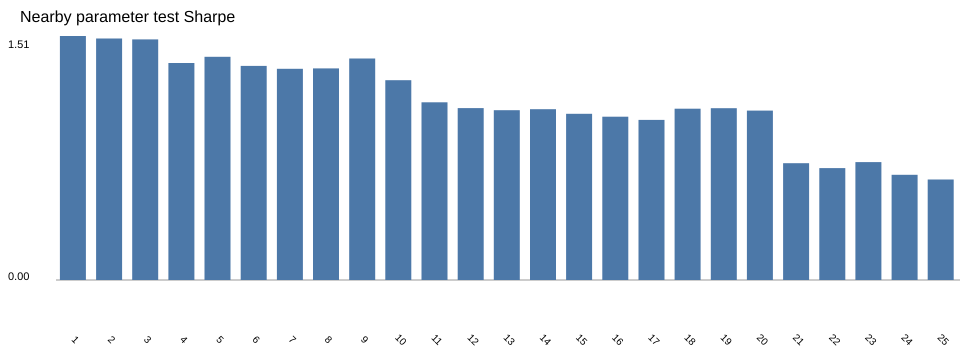

Neighbor pass fraction: 0.36


In [18]:
robust_rows = read_csv_rows(RESULTS_DIR / 'latest_strategy_search_robustness.csv')
neighbors = [row for row in robust_rows if row['check_type'] == 'parameter_neighbor']
costs = [row for row in robust_rows if row['check_type'] == 'cost_stress']
leave_one = [row for row in robust_rows if row['check_type'] == 'leave_one_out']
single_market = [row for row in robust_rows if row['check_type'] == 'single_market']

html_table(costs, columns=['item','passed','test_sharpe','test_annual_return','test_max_drawdown','failed_reasons'], title='Cost stress')
html_table(leave_one, columns=['item','passed','test_sharpe','test_annual_return','test_max_drawdown','failed_reasons'], title='Leave-one-market-out')
html_table(single_market, columns=['universe','passed','test_sharpe','test_annual_return','test_max_drawdown','failed_reasons'], title='Single-market breakdown')

neighbor_plot = []
for idx, row in enumerate(neighbors, start=1):
    neighbor_plot.append({'neighbor': idx, 'test_sharpe': row['test_sharpe'], 'passed': row['passed']})
bar_chart(neighbor_plot, 'neighbor', 'test_sharpe', 'Nearby parameter test Sharpe')
print('Neighbor pass fraction:', robustness.get('parameter_neighbor_summary', {}).get('pass_fraction'))

## 6. Walk-forward validation

The fixed confirmed strategy should make money in most out-of-sample folds. If the optimized strategy looks amazing in-sample but weak out-of-sample, that is overfitting.

fold,test_start,test_end,optimized_strategy,optimized_test_sharpe,optimized_test_annual_return,confirmed_test_sharpe,confirmed_test_annual_return,confirmed_test_max_drawdown
1,2008-01-18,2009-01-16,"momentum(lookback=20, threshold=0.1, side=inverse)",0.810883,0.984351,-0.489004,-0.105425,0.272446
2,2009-01-20,2010-01-19,"momentum(lookback=20, threshold=0.1, side=inverse)",1.518009,7.701756,1.697704,0.231516,0.081582
3,2010-01-20,2011-01-18,"momentum(lookback=90, threshold=0.1, side=inverse)",1.091965,3.638663,1.760852,0.759036,0.322459
4,2011-01-19,2012-01-18,"moving_average(band=0.005, fast=10, slow=300, side=inverse)",0.894763,0.410538,0.595611,0.180073,0.42343
5,2012-01-19,2013-01-16,"moving_average(band=0.005, fast=10, slow=300, side=inverse)",1.533031,1.411621,-2.189988,-0.317258,0.385593
6,2013-01-17,2014-01-16,"moving_average(band=0.0, fast=10, slow=300, side=inverse)",1.147472,0.371641,-0.508055,-0.101442,0.193367
7,2014-01-17,2015-01-16,"moving_average(band=0.0, fast=10, slow=300, side=inverse)",0.090953,-0.005612,-0.682613,-0.092526,0.206566
8,2015-01-20,2016-01-19,"moving_average(band=0.0, fast=10, slow=300, side=inverse)",1.681639,3.336802,-1.510712,-0.20576,0.20576
9,2016-01-20,2017-01-18,"moving_average(band=0.01, fast=5, slow=200, side=inverse)",1.023163,0.351793,1.325966,0.491134,0.190143
10,2017-01-19,2018-01-18,"moving_average(band=0.005, fast=10, slow=150, side=inverse)",0.47199,0.098032,0.095536,0.004529,0.091302


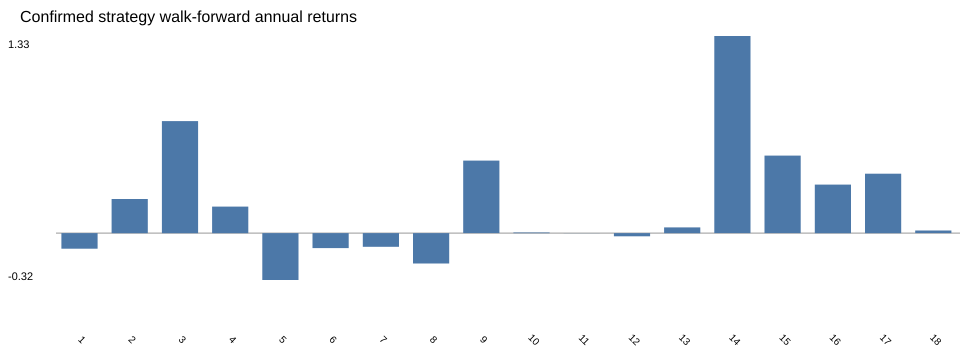

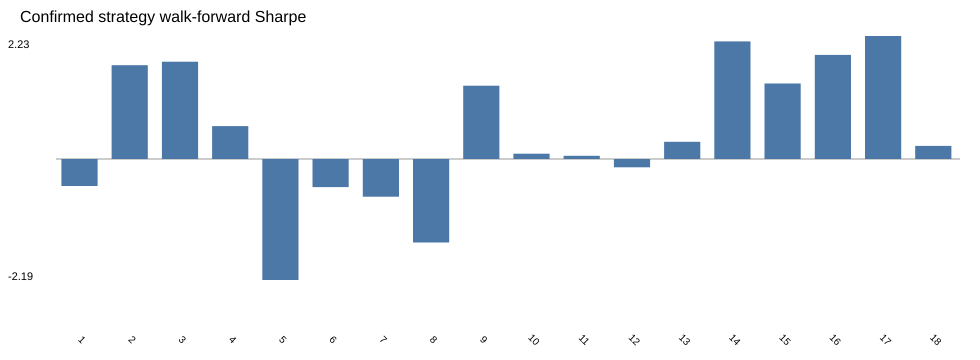

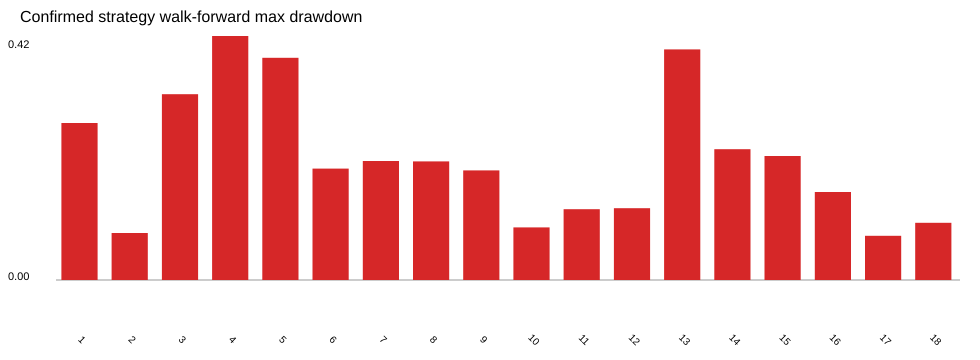

In [19]:
walk_rows = read_csv_rows(RESULTS_DIR / 'latest_strategy_search_walk_forward.csv')
selected_folds = [row for row in walk_rows if row['scope'] == 'selected_universe_optimized']
cross_folds = [row for row in walk_rows if row['scope'] == 'cross_universe_confirmed']

html_table(selected_folds, columns=['fold','test_start','test_end','optimized_strategy','optimized_test_sharpe','optimized_test_annual_return','confirmed_test_sharpe','confirmed_test_annual_return','confirmed_test_max_drawdown'], limit=25, title='Selected-universe walk-forward folds')
bar_chart(selected_folds, 'fold', 'confirmed_test_annual_return', 'Confirmed strategy walk-forward annual returns')
bar_chart(selected_folds, 'fold', 'confirmed_test_sharpe', 'Confirmed strategy walk-forward Sharpe')
bar_chart(selected_folds, 'fold', 'confirmed_test_max_drawdown', 'Confirmed strategy walk-forward max drawdown', color='#d62728')

## 7. Cross-universe walk-forward

This applies the confirmed strategy across every predefined universe. A robust idea should not only work on the exact selected universe.

universe,folds,positive_return_fraction,mean_ann_return,mean_sharpe,worst_drawdown
all,18,0.6111111111111112,0.028168222222222223,0.35520816666666666,0.101332
all_ex_vx_btc,18,0.6111111111111112,0.028170611111111115,0.3462516666666666,0.101332
commodities,18,0.5,0.05693416666666667,0.1262993888888889,0.177952
currencies,18,0.6111111111111112,0.008961944444444446,0.13134705555555556,0.082786
energies,18,0.3888888888888889,0.07292944444444444,-0.06457244444444446,0.515161
equity_index,18,0.5,0.024342166666666665,0.2005647777777778,0.125698
grains_oilseeds,18,0.4444444444444444,0.02138316666666667,-0.05975300000000002,0.306599
livestock,16,0.4375,0.001625187499999999,-0.2976785,0.12075
metals,18,0.3333333333333333,0.005373499999999999,-0.0853235,0.146498
rates,18,0.5555555555555556,0.004630111111111111,0.061024277777777775,0.085386


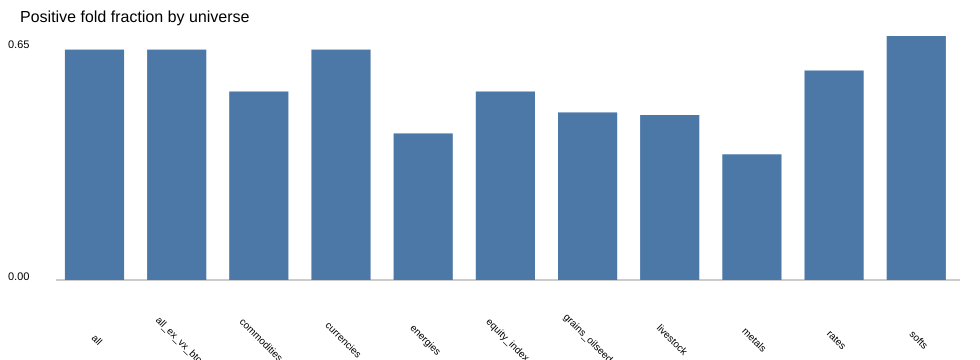

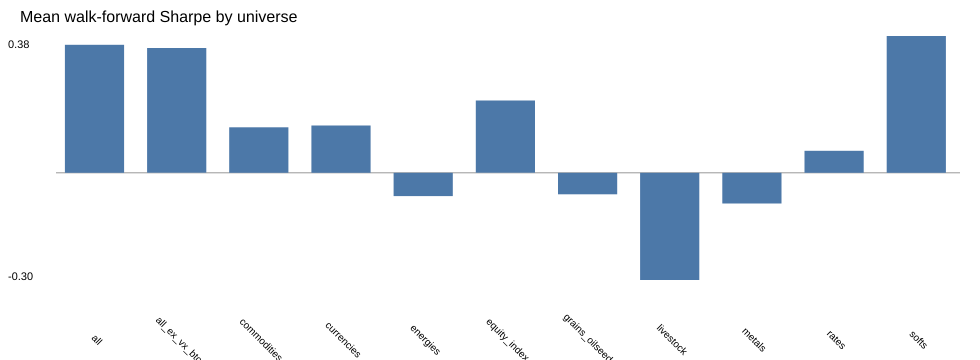

In [20]:
by_universe = defaultdict(list)
for row in cross_folds:
    by_universe[row['universe']].append(row)

cross_summary = []
for universe, rows in sorted(by_universe.items()):
    ann = [float(row['confirmed_test_annual_return']) for row in rows if row['confirmed_test_annual_return']]
    shp = [float(row['confirmed_test_sharpe']) for row in rows if row['confirmed_test_sharpe']]
    dd = [float(row['confirmed_test_max_drawdown']) for row in rows if row['confirmed_test_max_drawdown']]
    if not ann:
        continue
    cross_summary.append({
        'universe': universe,
        'folds': len(rows),
        'positive_return_fraction': sum(1 for value in ann if value > 0) / len(ann),
        'mean_ann_return': sum(ann) / len(ann),
        'mean_sharpe': sum(shp) / len(shp),
        'worst_drawdown': max(dd),
    })

html_table(cross_summary, title='Cross-universe confirmed-strategy walk-forward summary')
bar_chart(cross_summary, 'universe', 'positive_return_fraction', 'Positive fold fraction by universe')
bar_chart(cross_summary, 'universe', 'mean_sharpe', 'Mean walk-forward Sharpe by universe')

## Review rule of thumb

A strategy is only a serious candidate if all of these are true:

- search status passed
- robustness status passed
- walk-forward status passed
- most nearby parameter variants passed
- most walk-forward folds are positive
- drawdowns are acceptable in train, validation, test, and walk-forward
- it works across enough markets to avoid one-market dependence

If the search passes but robustness is flagged, treat it as a research lead, not a trading strategy.